<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 10</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Business value</div><div style="font-size:1.05em;opacity:0.85">What the model is worth in money — and under which assumptions.</div></div>

Stages 07–09 built and explained a model that ranks well and stays calibrated. This stage asks
the question the project exists for: **how much money does a retention campaign built on it
make**, compared with the alternatives, and how far does that answer depend on assumptions
nobody measured? Every profit below is a backtest on the September 2011 test cutoff: the
policy decides from the model's probabilities, and the outcome is judged against what the
customers actually did in the following 90 days.

**Pipeline rule.** The policy table with its CIs comes from `reports/evaluation.json`
(`churnvalue evaluate`). Curves and scenarios use `churnvalue.policy` on the exported customer
file (`artifacts/customers.json`) — the same inputs the web app's simulator uses.

| | |
|---|---|
| **Input** | `reports/evaluation.json` · `artifacts/customers.json` |
| **Outputs** | `reports/results/10_summary.json` · `reports/figures/10_*.png` |
| **Parameters** | `configs/default.yaml` → `economics` (margin 0.35, λc 0.10, λa 10, γ 0.30, c £1, T 365 d) |
| **Shared code** | `churnvalue.policy` · `churnvalue.economics` · `churnvalue.evaluate` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">$1 policies</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">$2 how many to contact</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">$3 budget</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">$4 assumptions</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">$5 acquisition cost</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from churnvalue.config import load_config, project_root
from churnvalue.economics import break_even_limit
from churnvalue.policy import budget_curve, profit_curve, sensitivity_grid
from churnvalue.reporting import StageSummary
from churnvalue.viz import style
from churnvalue.viz.style import DIVERGING, INK, MODEL_COLORS, MODEL_LABELS, MUTED, ORACLE_COLOR

os.chdir(project_root())
CFG = load_config()
ECON = CFG.economics
STAGE, FIGURES, RESULTS = "10", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


report = json.loads((CFG.reports_dir / "evaluation.json").read_text(encoding="utf-8"))
customers = json.loads((CFG.artifacts_dir / "customers.json").read_text(encoding="utf-8"))
frame = pd.DataFrame(
    [
        {
            "churn": c["churn"],
            "aov": c["aov_gg"],
            "cadence": c["cadence_days"],
            **{f"p_{name}": p for name, p in c["p"].items()},
        }
        for c in customers["customers"]
    ]
)
y = frame["churn"].to_numpy(float)
DEPLOYED = customers["deployed_model"]
policies = pd.DataFrame(report["policies"]).set_index("policy")
oracle = policies.loc["oracle", "realized_profit"]
DEFAULTS = (
    f"margin {ECON.margin:.0%} · λc {ECON.lambda_c} · λa {ECON.lambda_a:g} · "
    f"γ {ECON.gamma} · £{ECON.contact_cost:g} per contact"
)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">$1 · Policies</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the deployed model makes money, and says so in advance</span></div>

Each policy contacts every customer whose expected profit is positive, using its own calibrated
probabilities. Contacting everyone loses £128k: most customers would have stayed anyway and
still collect the incentive. BG/NBD expects £126k and loses £23k. The supervised models all
make money; **LightGBM + season makes the most and is the only one whose expected profit is
close to what it realized**. The others promise several times what they deliver — the money
face of the calibration drift of stage 08.

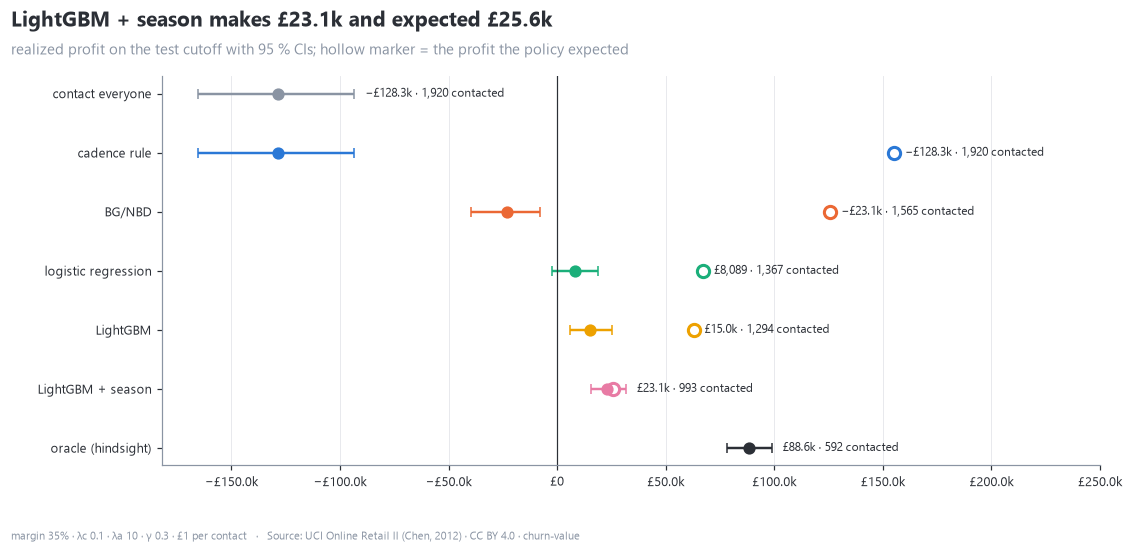

In [2]:
order = [
    "contact_all",
    "cadence_rule",
    "bgnbd",
    "logreg",
    "lightgbm",
    "lightgbm_seasonal",
    "oracle",
]
names = {"contact_all": "contact everyone", "oracle": "oracle (hindsight)", **MODEL_LABELS}
colors = {"contact_all": MUTED, "oracle": ORACLE_COLOR, **MODEL_COLORS}
fig, ax = plt.subplots(figsize=(11, 4.6))
ys = np.arange(len(order))[::-1]
for yi, key in zip(ys, order, strict=True):
    row = policies.loc[key]
    ax.errorbar(
        row["realized_profit"],
        yi,
        xerr=[
            [row["realized_profit"] - row["realized_profit_ci_low"]],
            [row["realized_profit_ci_high"] - row["realized_profit"]],
        ],
        fmt="o",
        color=colors[key],
        capsize=3,
        markersize=7,
        lw=1.6,
    )
    if pd.notna(row["expected_profit"]) and key in MODEL_COLORS:
        ax.plot(
            row["expected_profit"],
            yi,
            "o",
            markerfacecolor="white",
            markeredgecolor=colors[key],
            markersize=8,
            markeredgewidth=2,
        )
    label = f"{style.gbp(row['realized_profit'])} · {int(row['n_contacted']):,} contacted"
    ax.text(
        max(
            row["realized_profit_ci_high"],
            row["expected_profit"] if pd.notna(row["expected_profit"]) else -1e9,
        )
        + 5_000,
        yi,
        label,
        va="center",
        fontsize=8,
        color=INK,
    )
ax.axvline(0, color=INK, lw=0.8)
ax.set_yticks(ys, [names[k] for k in order])
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.set_xlim(policies["realized_profit_ci_low"].min() * 1.1, 250_000)
deployed_row = policies.loc[DEPLOYED]
S["policies"] = policies[
    [
        "n_contacted",
        "expected_profit",
        "realized_profit",
        "realized_profit_ci_low",
        "realized_profit_ci_high",
        "share_of_oracle",
    ]
].to_dict("index")
S["deployed_expected_over_realized"] = (
    deployed_row["expected_profit"] / deployed_row["realized_profit"]
)
S["lightgbm_expected_over_realized"] = (
    policies.loc["lightgbm", "expected_profit"] / policies.loc["lightgbm", "realized_profit"]
)
style.headline(
    fig,
    f"LightGBM + season makes {style.gbp(deployed_row['realized_profit'])} and expected "
    f"{style.gbp(deployed_row['expected_profit'])}",
    "realized profit on the test cutoff with 95 % CIs; "
    "hollow marker = the profit the policy expected",
)
style.add_source(fig, DEFAULTS)
save(fig, "policies")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">$2 · How many to contact</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">calibration picks the right stopping point</span></div>

Rank customers by expected profit and contact them one by one: the cumulative profit rises
while the next customer is worth contacting and falls afterwards. The policy stops where
expected profit turns negative. For LightGBM + season that point is within a few percent of the
best stopping point in hindsight. The plain LightGBM ranks as well, but its over-confident
probabilities keep it contacting customers long after the realized curve has turned down.

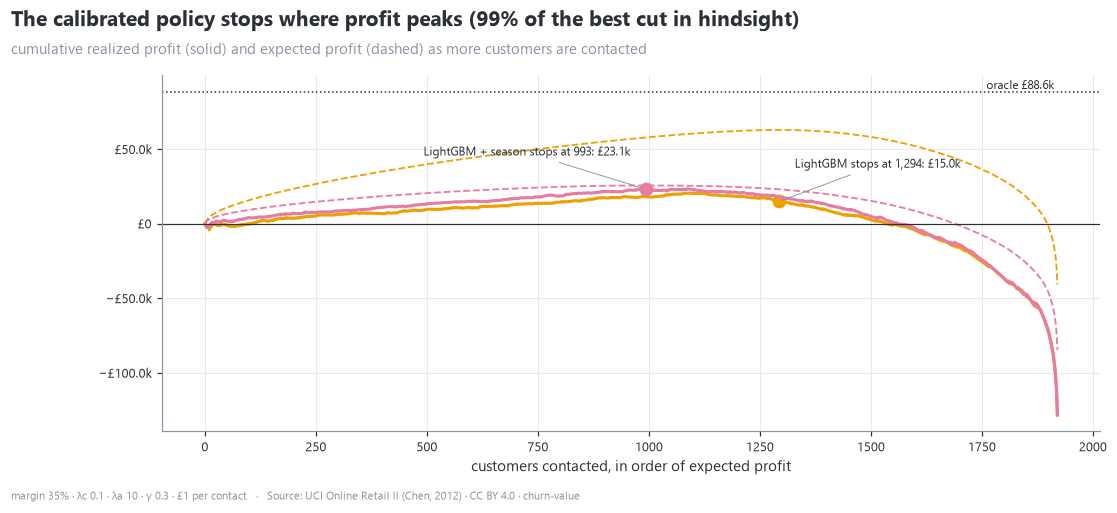

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.2))
stops = {}
for name in ["lightgbm", DEPLOYED]:
    curve = profit_curve(y, frame[f"p_{name}"], frame["aov"], frame["cadence"], ECON)
    k_stop = int((curve["expected_profit"].diff().fillna(0) > 0).sum())
    k_best = int(curve["realized_profit"].idxmax())
    stops[name] = {
        "k_stop": k_stop,
        "realized_at_stop": curve["realized_profit"][k_stop],
        "k_best": k_best,
        "realized_best": curve["realized_profit"].max(),
    }
    ax.plot(curve["k"], curve["realized_profit"], color=MODEL_COLORS[name], lw=2)
    ax.plot(curve["k"], curve["expected_profit"], color=MODEL_COLORS[name], lw=1.2, ls="--")
    ax.plot(k_stop, curve["realized_profit"][k_stop], "o", color=MODEL_COLORS[name], markersize=8)
    ax.annotate(
        f"{MODEL_LABELS[name]} stops at {k_stop:,}: {style.gbp(curve['realized_profit'][k_stop])}",
        (k_stop, curve["realized_profit"][k_stop]),
        xytext=(-10, 22) if name == DEPLOYED else (10, 22),
        textcoords="offset points",
        ha="right" if name == DEPLOYED else "left",
        fontsize=8,
        color=INK,
        arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.6},
    )
ax.axhline(oracle, color=ORACLE_COLOR, lw=1, ls=":")
ax.text(
    len(frame),
    oracle,
    f"oracle {style.gbp(oracle)} ",
    ha="right",
    va="bottom",
    fontsize=8,
    color=INK,
)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("customers contacted, in order of expected profit")
ax.yaxis.set_major_formatter(lambda v, _: style.gbp(v))
S["stopping"] = stops
share = stops[DEPLOYED]["realized_at_stop"] / stops[DEPLOYED]["realized_best"]
S["deployed_stop_share_of_best"] = share
style.headline(
    fig,
    f"The calibrated policy stops where profit peaks ({share:.0%} of the best cut in hindsight)",
    "cumulative realized profit (solid) and expected profit (dashed) "
    "as more customers are contacted",
)
style.add_source(fig, DEFAULTS)
save(fig, "profit_curve")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">$3 · Budget</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">what a smaller campaign buys</span></div>

A retention team rarely gets an open cheque. In budget mode the policy takes customers in order
of expected profit until the **expected spend** — the contact cost plus the incentive paid to
everyone who accepts, churner or not — reaches the budget. The first customers are the largest
and their outcomes are noisy, so small budgets realize little; the realized profit catches up
with the expected one as the campaign grows, and the curve flattens once every customer with a
positive expected profit is in.

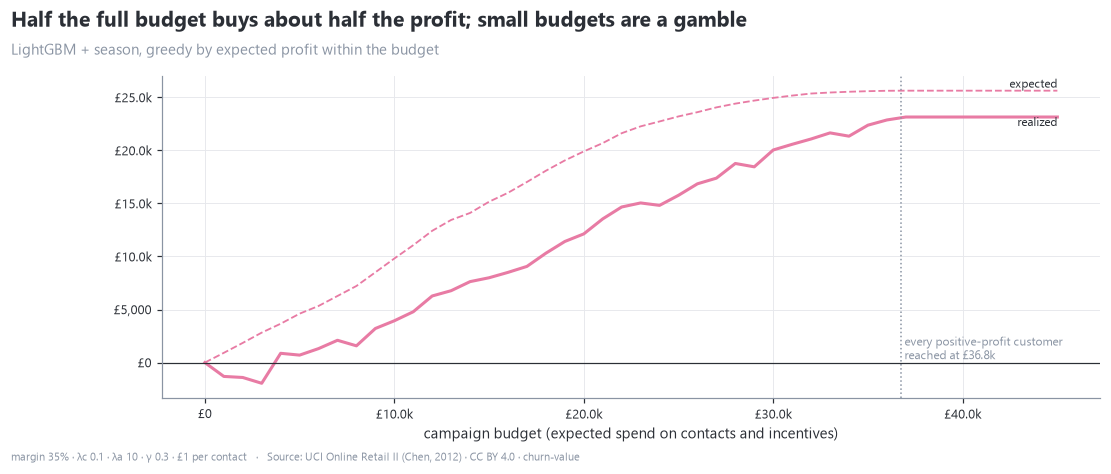

In [4]:
budgets = np.linspace(0, 45_000, 46)
budget = budget_curve(y, frame[f"p_{DEPLOYED}"], frame["aov"], frame["cadence"], ECON, budgets)
full = budget["expected_spend"].max()
S["full_campaign_expected_spend"] = full
S["budget_points"] = budget.set_index("budget").loc[[10_000.0, 20_000.0, 30_000.0]].to_dict("index")
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(budget["budget"], budget["realized_profit"], color=MODEL_COLORS[DEPLOYED], lw=2)
ax.plot(budget["budget"], budget["expected_profit"], color=MODEL_COLORS[DEPLOYED], lw=1.2, ls="--")
ax.text(
    budgets[-1],
    budget["expected_profit"].iloc[-1],
    " expected",
    va="bottom",
    ha="right",
    fontsize=8,
    color=INK,
)
ax.text(
    budgets[-1],
    budget["realized_profit"].iloc[-1],
    " realized",
    va="top",
    ha="right",
    fontsize=8,
    color=INK,
)
ax.axvline(full, color=MUTED, lw=1, ls=":")
ax.text(
    full,
    0,
    f" every positive-profit customer\n reached at {style.gbp(full)}",
    fontsize=8,
    color=MUTED,
    va="bottom",
)
ax.axhline(0, color=INK, lw=0.8)
ax.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.yaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.set_xlabel("campaign budget (expected spend on contacts and incentives)")
style.headline(
    fig,
    "Half the full budget buys about half the profit; small budgets are a gamble",
    f"{MODEL_LABELS[DEPLOYED]}, greedy by expected profit within the budget",
)
style.add_source(fig, DEFAULTS)
save(fig, "budget")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">$4 · Assumptions</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">where the campaign pays, and what calibration protects</span></div>

Two assumptions matter most and neither was measured: γ, the share of contacted churners who
accept the incentive and stay, and λc, the incentive as a share of the customer's value. The
heatmaps re-run the whole policy — probabilities fixed, economics recomputed — on a grid of
both. The deployed model's policy **loses at most about £50 anywhere on this grid**: when the
economics turn bad, calibrated probabilities make it contact fewer customers, down to none. The
plain LightGBM, over-confident after the season change, loses money in a third of the cells —
wherever the campaign is marginal.
Profit peaks at λc = 0.10 because, with λa = 10, that is where the acquisition cost of
replacing a customer first covers their whole value (next section).

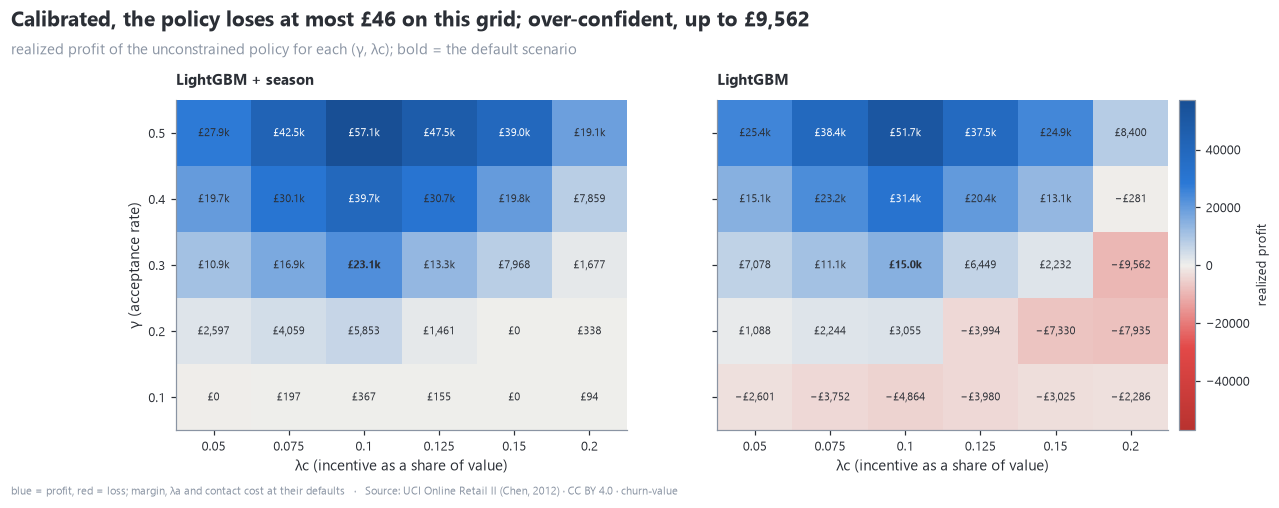

In [5]:
gammas = [0.1, 0.2, 0.3, 0.4, 0.5]
lambda_cs = [0.05, 0.075, 0.10, 0.125, 0.15, 0.20]
grids = {
    name: sensitivity_grid(
        y, frame[f"p_{name}"], frame["aov"], frame["cadence"], ECON, gammas, lambda_cs
    ).pivot(index="gamma", columns="lambda_c", values="realized_profit")
    for name in [DEPLOYED, "lightgbm"]
}
limit = max(abs(g.to_numpy()).max() for g in grids.values())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
for ax, (name, grid) in zip(axes, grids.items(), strict=True):
    image = ax.imshow(grid.to_numpy()[::-1], cmap=DIVERGING, vmin=-limit, vmax=limit, aspect="auto")
    for i, gamma in enumerate(grid.index[::-1]):
        for j, lc in enumerate(grid.columns):
            value = grid.loc[gamma, lc]
            ax.text(
                j,
                i,
                style.gbp(value) if abs(value) >= 50 else "£0",
                ha="center",
                va="center",
                fontsize=7.5,
                color="white" if abs(value) > 0.55 * limit else INK,
                fontweight="bold" if (gamma == ECON.gamma and lc == ECON.lambda_c) else "normal",
            )
    ax.set_xticks(range(len(grid.columns)), [f"{c:g}" for c in grid.columns])
    ax.set_yticks(range(len(grid.index)), [f"{g:g}" for g in grid.index[::-1]])
    ax.set_xlabel("λc (incentive as a share of value)")
    ax.set_title(MODEL_LABELS[name], fontsize=9.5)
    ax.grid(False)
axes[0].set_ylabel("γ (acceptance rate)")
fig.colorbar(image, ax=axes, fraction=0.02, pad=0.01).set_label("realized profit", fontsize=8.5)
S["grid_deployed_min"] = float(grids[DEPLOYED].to_numpy().min())
S["grid_lightgbm_min"] = float(grids["lightgbm"].to_numpy().min())
S["grid_lightgbm_losing_cells"] = int((grids["lightgbm"].to_numpy() < 0).sum())
S["grid_cells"] = int(grids["lightgbm"].size)
style.headline(
    fig,
    f"Calibrated, the policy loses at most {style.gbp(-S['grid_deployed_min'])} on this grid; "
    f"over-confident, up to {style.gbp(-S['grid_lightgbm_min'])}",
    "realized profit of the unconstrained policy for each (γ, λc); bold = the default scenario",
)
style.add_source(fig, "blue = profit, red = loss; margin, λa and contact cost at their defaults")
save(fig, "sensitivity")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">$5 · Acquisition cost</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the benefit of keeping a customer is capped by their value</span></div>

Keeping a churner is worth the cheaper of two things: their value *V*, or the cost of acquiring
a replacement, CAC = λa × λc × *V* (the origin project's coupling, kept explicit). While λa × λc
is below 1, a higher acquisition cost makes retention more valuable; once it reaches 1 the
benefit is capped at *V* and raising λa changes nothing. With λc = 0.10 the cap is reached at
λa = 10, the default. Below it the campaign shrinks fast: the break-even churn probability for
large customers rises from 0.27 at the default to 0.77 at λa = 2, where nobody is worth
contacting.

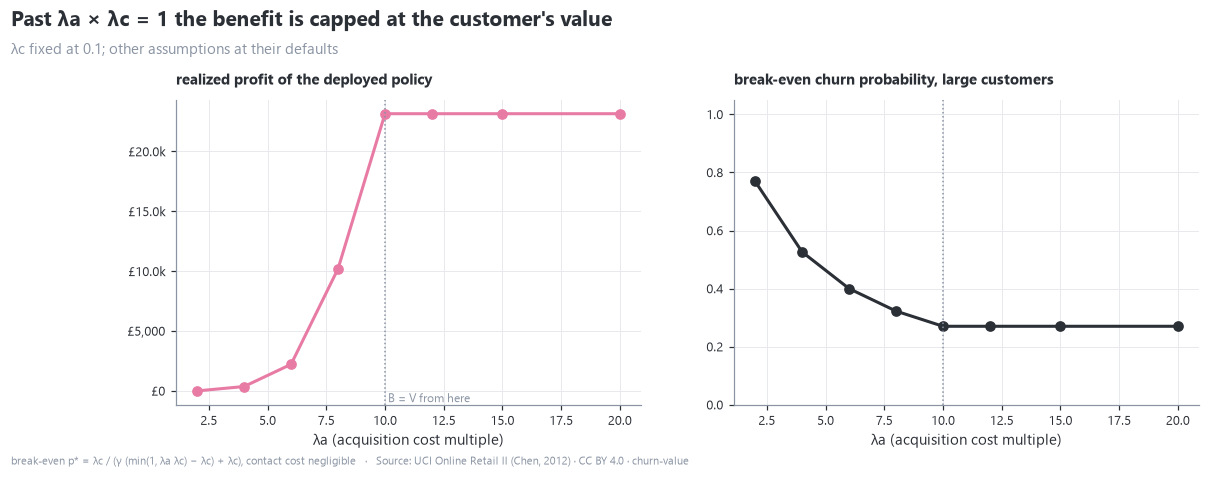

,contacted,realized_profit,break_even_p
lambda_a,,,
2,0,£0,0.77
4,261,£367,0.53
6,549,"£2,221",0.40
8,810,"£10,196",0.32
10,993,"£23,139",0.27
12,993,"£23,139",0.27
15,993,"£23,139",0.27
20,993,"£23,139",0.27


In [6]:
rows = []
for lambda_a in [2, 4, 6, 8, 10, 12, 15, 20]:
    scenario = ECON.model_copy(update={"lambda_a": float(lambda_a)})
    curve = profit_curve(y, frame[f"p_{DEPLOYED}"], frame["aov"], frame["cadence"], scenario)
    k_stop = int((curve["expected_profit"].diff().fillna(0) > 0).sum())
    rows.append(
        {
            "lambda_a": lambda_a,
            "contacted": k_stop,
            "realized_profit": curve["realized_profit"][k_stop],
            "break_even_p": break_even_limit(scenario),
        }
    )
acquisition = pd.DataFrame(rows).set_index("lambda_a")
S["acquisition"] = acquisition.to_dict("index")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(acquisition.index, acquisition["realized_profit"], "o-", color=MODEL_COLORS[DEPLOYED])
axes[0].yaxis.set_major_formatter(lambda v, _: style.gbp(v))
axes[0].set_title("realized profit of the deployed policy", fontsize=9.5)
axes[1].plot(acquisition.index, acquisition["break_even_p"], "o-", color=INK)
axes[1].set_title("break-even churn probability, large customers", fontsize=9.5)
axes[1].set_ylim(0, 1.05)
for ax in axes:
    ax.axvline(1 / ECON.lambda_c, color=MUTED, lw=1, ls=":")
    ax.set_xlabel("λa (acquisition cost multiple)")
axes[0].text(
    1 / ECON.lambda_c,
    axes[0].get_ylim()[0],
    " B = V from here",
    fontsize=8,
    color=MUTED,
    va="bottom",
)
style.headline(
    fig,
    "Past λa × λc = 1 the benefit is capped at the customer's value",
    f"λc fixed at {ECON.lambda_c}; other assumptions at their defaults",
)
style.add_source(fig, "break-even p* = λc / (γ (min(1, λa λc) − λc) + λc), contact cost negligible")
save(fig, "acquisition")
plt.show()
display(acquisition.style.format({"realized_profit": "£{:,.0f}", "break_even_p": "{:.2f}"}))

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">10 → 11, web app</span></div>

**Produced** — `reports/results/10_summary.json` and the figures `10_policies`,
`10_profit_curve`, `10_budget`, `10_sensitivity`, `10_acquisition`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>At the default assumptions the deployed policy realizes about a quarter of the oracle's profit, with an interval above zero, and expected about what it made. The plain LightGBM ranks as well but expects about four times what it makes.</li><li>Calibration is also insurance: across plausible acceptance rates and incentive sizes the calibrated policy loses at most a few tens of pounds, because it contacts fewer customers when the economics are poor; the over-confident one loses up to about £10k.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>The simulator's defaults stay as configured (λc 0.10, λa 10, γ 0.30); the web app lets users move every assumption and shows expected and realized profit side by side.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>11_ablation</b> — how much of this comes from the month features, from one censored feature and from the random seed.</li><li>Plan 3 — the same computations in the browser (golden vectors guarantee they match).</li></ul></div>

In [7]:
S.write(RESULTS)

WindowsPath('reports/results/10_summary.json')